### PACE Collocation

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.path import Path as MplPath
from py_eddy_tracker.observations.tracking import TrackEddiesObservations
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

TRACK_ID = 13
DATE = "2025-03-29"
WAVELENGTH = 442

In [2]:
# Load PACE L3 daily Rrs
date_str = DATE.replace("-", "")
pace_path = ROOT / "data" / "gulf_stream_20241001_20250701" / "pace_l3" / f"PACE_OCI.{date_str}.L3m.DAY.RRS.V3_1.Rrs.4km.nc"
pace = xr.open_dataset(pace_path)

wl = pace["wavelength"].values
wl_idx = np.argmin(np.abs(wl - WAVELENGTH))

# Load cyclone tracks and find the target observation
tracks_path = ROOT / "outputs" / "gulf_stream_cyclonic" / "eddy_track" / "cyclone" / "cyclone_tracks.zarr"
t = TrackEddiesObservations.load_file(str(tracks_path))

mask = t["track"] == TRACK_ID
obs_idx = np.where(mask)[0]
epoch = np.datetime64("1950-01-01")
target_day = (np.datetime64(DATE) - epoch) / np.timedelta64(1, "D")
closest = np.argmin(np.abs(t["time"][mask] - target_day))
idx = obs_idx[closest]

# Eddy contour
clons = t["contour_lon_e"][idx].copy()
clats = t["contour_lat_e"][idx].copy()
clons[clons > 180] -= 360
poly_lons = np.append(clons, clons[0])
poly_lats = np.append(clats, clats[0])

print(f"Eddy {TRACK_ID} on {DATE}")
print(f"Effective radius: {t['radius_e'][idx]/1000:.1f} km")

Eddy 13 on 2025-03-29
Effective radius: 100.0 km


In [3]:
# Square symmetric extent rounded to 0.5° gridline alignment, then trim 0.5° off each lat edge
center_lon = (clons.min() + clons.max()) / 2
center_lat = (clats.min() + clats.max()) / 2
half_span = max(clons.max() - clons.min(), clats.max() - clats.min()) / 2 + 0.7

def round_half(x, direction):
    return np.floor(x * 2) / 2 if direction == "down" else np.ceil(x * 2) / 2

west = round_half(center_lon - half_span, "down")
east = round_half(center_lon + half_span, "up")
south = round_half(center_lat - half_span, "down")
north = round_half(center_lat + half_span, "up")
w, h = east - west, north - south
if w < h:
    diff = h - w
    west = round_half(west - diff/2, "down")
    east = round_half(east + diff/2, "up")
elif h < w:
    diff = w - h
    south = round_half(south - diff/2, "down")
    north = round_half(north + diff/2, "up")

# Trim latitude padding to make the plot less tall
LAT_INSET = 0.5
south += LAT_INSET
north -= LAT_INSET
extent = [west, east, south, north]

# Subset PACE grid
lon = pace["lon"].values
lat = pace["lat"].values
lon_mask = (lon >= extent[0]) & (lon <= extent[1])
lat_mask = (lat >= extent[2]) & (lat <= extent[3])
lon_sub = lon[lon_mask]
lat_sub = lat[lat_mask]
rrs_sub = pace["Rrs"].values[np.ix_(lat_mask, lon_mask)][:, :, wl_idx]

# Inside-contour mask
contour_path = MplPath(np.column_stack([clons, clats]))
lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)
points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
inside = contour_path.contains_points(points).reshape(lon_grid.shape)

n_inside = inside.sum()
n_valid = (inside & np.isfinite(rrs_sub)).sum()
coverage = n_valid / n_inside
print(f"Pixels inside contour: {n_inside}")
print(f"Valid (non-NaN): {n_valid}")
print(f"Within-eddy coverage: {coverage:.3f}")

Pixels inside contour: 1743
Valid (non-NaN): 1644
Within-eddy coverage: 0.943


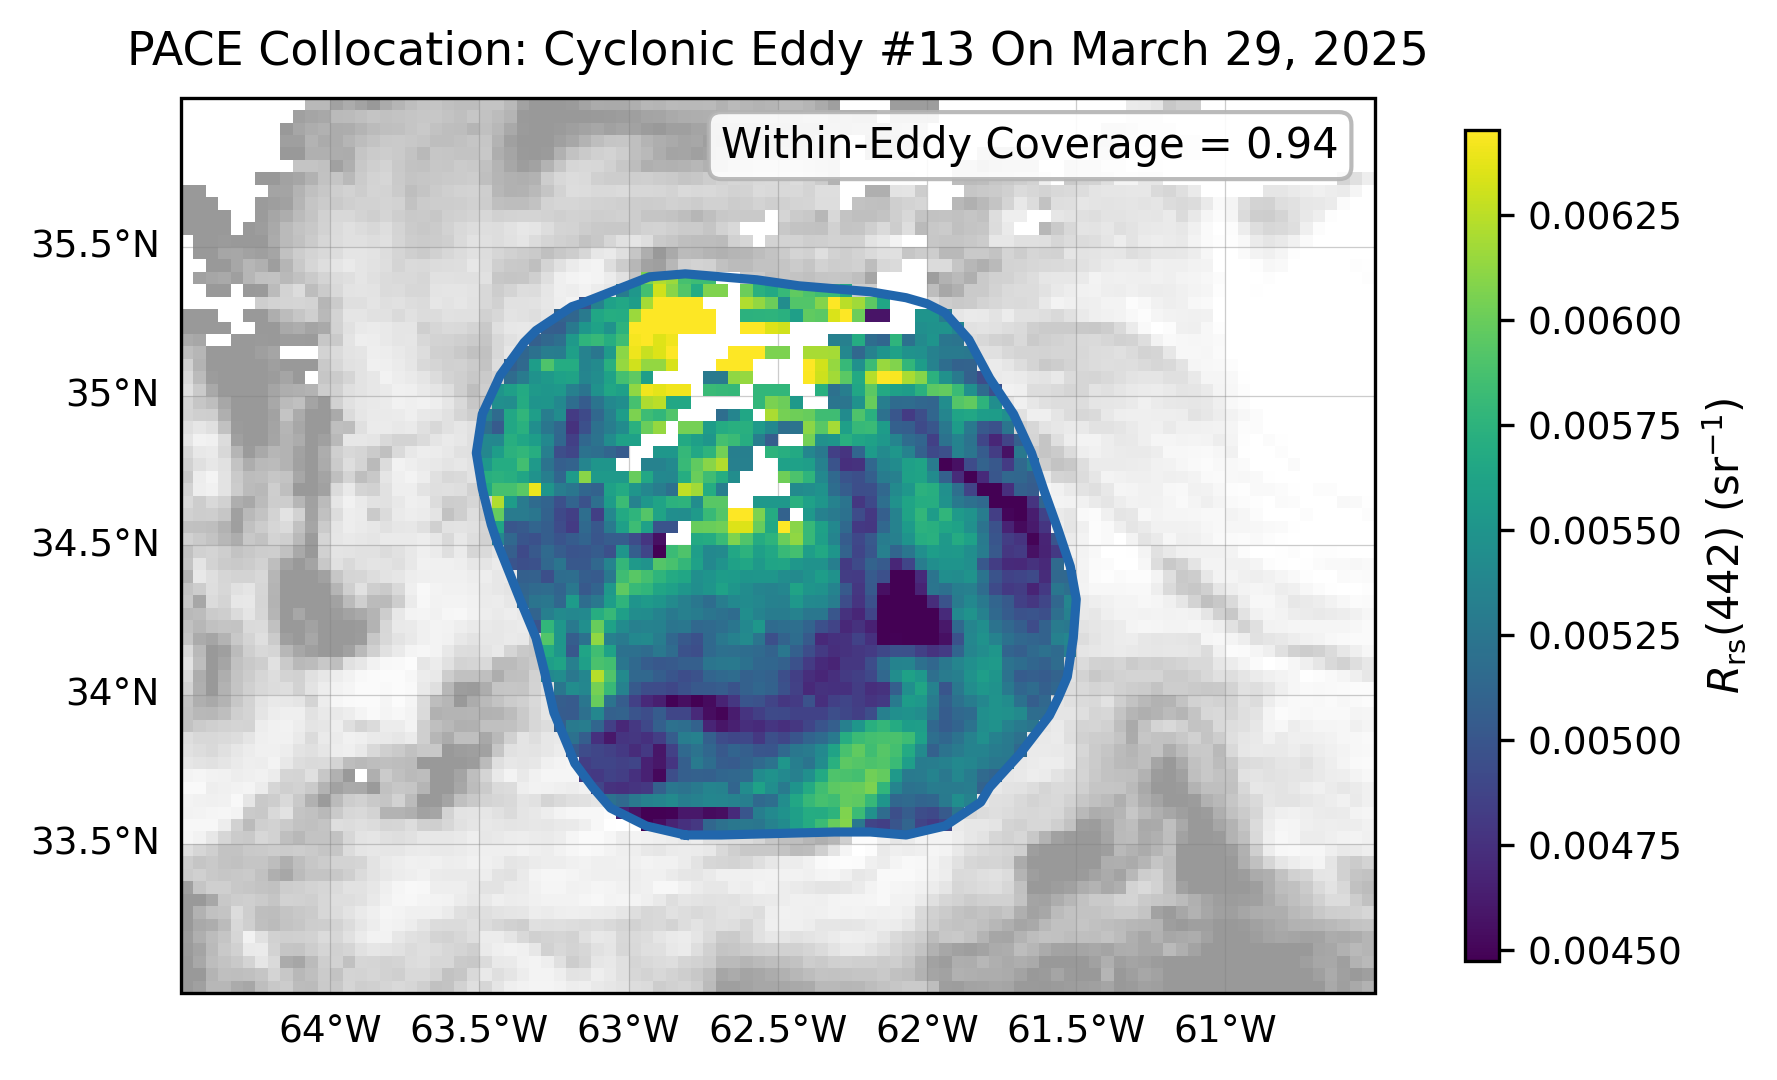

In [4]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=300, subplot_kw={"projection": proj})
ax.set_extent(extent, crs=proj)
ax.set_facecolor("white")

# Outside contour: muted grayscale showing spatial Rrs pattern
rrs_outside = rrs_sub.copy()
rrs_outside[inside] = np.nan
out_vmin = np.nanpercentile(rrs_outside, 5)
out_vmax = np.nanpercentile(rrs_outside, 95)
ax.pcolormesh(lon_sub, lat_sub, rrs_outside, cmap="Greys",
              vmin=out_vmin, vmax=out_vmax, transform=proj, zorder=1, alpha=0.4)

# Inside contour: viridis Rrs
rrs_color = rrs_sub.copy()
rrs_color[~inside] = np.nan
vmin = np.nanpercentile(rrs_sub[inside], 2)
vmax = np.nanpercentile(rrs_sub[inside], 98)
cf = ax.pcolormesh(lon_sub, lat_sub, rrs_color, cmap="viridis",
                   vmin=vmin, vmax=vmax, transform=proj, zorder=3)

# Eddy contour boundary
ax.plot(poly_lons, poly_lats, color="#2166ac", lw=2.2, transform=proj, zorder=5)

# Within-eddy coverage label in top-right
ax.text(0.97, 0.97, f"Within-Eddy Coverage = {coverage:.2f}", transform=ax.transAxes,
        fontsize=10, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
        zorder=10)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.5", alpha=0.4, zorder=7)
gl.top_labels = gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}
gl.xlocator = mticker.FixedLocator(np.arange(extent[0], extent[1] + 0.1, 0.5))
gl.ylocator = mticker.FixedLocator(np.arange(extent[2], extent[3] + 0.1, 0.5))

# Colorbar
cbar = fig.colorbar(cf, ax=ax, orientation="vertical", shrink=0.75, pad=0.06, aspect=25)
cbar.set_label(r"$R_{\mathrm{rs}}$(442) (sr$^{-1}$)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

date_obj = datetime.strptime(DATE, "%Y-%m-%d")
ax.set_title(f"PACE Collocation: Cyclonic Eddy #{TRACK_ID} On {date_obj.strftime('%B %d, %Y')}",
             fontsize=11, pad=8)

fig.savefig("pace_collocation.png", dpi=300, bbox_inches="tight")
plt.show()